# 03 — Storm-First Sample Construction

## Purpose

Notebooks 01 and 02 established two points:

1. the summer negative label means **no nearby observed NOAA hail report**, not necessarily a non-hail storm;
2. MRMS composite reflectivity can provide independent evidence of convective storm occurrence.

This notebook therefore reverses the original sampling order.

Instead of

$$
\text{hail report}
\rightarrow
\text{candidate negative},
$$

the storm-first construction uses

$$
\text{MRMS radar}
\rightarrow
S
\rightarrow
\text{NOAA hail overlay}
\rightarrow
H.
$$

Here,

$$
S = \text{radar-defined storm occurrence},
\qquad
H = \text{observed NOAA hail occurrence}.
$$

The resulting sample frame is designed to support the conditional estimand

$$
P(H=1 \mid S=1, X).
$$

The radar definition of $S$ is constructed without using hail reports. NOAA hail observations are attached only afterward.

## 1. Operational storm definition

The working spatial unit is a

$$
0.25^\circ \times 0.25^\circ
$$

grid cell evaluated over one radar hour.

MRMS `MergedReflectivityQCComposite_00.50` is available at approximately 0.01° resolution and roughly two-minute cadence.

A scan-cell is considered usable when at least 80% of its nominal fine-grid pixels contain valid reflectivity.

For each usable scan-cell, spatial support is defined relative to the **full nominal 0.25° cell**:

$$
A_{35}
=
\frac{
\#\{\text{fine pixels with } Z\ge35\text{ dBZ}\}
}{
625
}.
$$

The provisional strict storm rule is:

- reflectivity threshold: **35 dBZ**;
- spatial support: at least **10% of the full coarse cell**;
- temporal persistence: at least **5 radar scans within the hour**;
- grid-hour coverage: at least **80% of scans** must themselves satisfy the 80% fine-pixel coverage requirement.

Two sensitivity definitions are retained:

- **moderate:** ≥5% area in ≥3 scans;
- **very strict:** ≥10% area in ≥10 scans.

These definitions are treated as scientific design choices rather than model-performance tuning parameters.

In [1]:
from pathlib import Path
import gzip
import re
import shutil

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Locate repository root
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "data").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "data").exists():
    REPO_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate repository data directory. "
        "Run this notebook from the repository root or notebooks/."
    )


DATA_DIR = REPO_ROOT / "data"

MRMS_DIR = DATA_DIR / "mrms"

HAIL_PATH = (
    DATA_DIR
    / "hail_records"
    / "Combined US Hail Data.csv"
)


if not MRMS_DIR.exists():
    raise FileNotFoundError(
        f"MRMS directory not found: {MRMS_DIR}\n"
        "See data/README.md for local data setup."
    )

if not HAIL_PATH.exists():
    raise FileNotFoundError(
        f"NOAA hail file not found: {HAIL_PATH}\n"
        "See data/README.md for local data setup."
    )

In [2]:
# ------------------------------------------------------------
# Spatial domain
# ------------------------------------------------------------

LAT_MIN = 37.5
LAT_MAX = 40.5

LON_MIN = -92.0
LON_MAX = -88.5


# ------------------------------------------------------------
# MRMS / coarse-grid definitions
# ------------------------------------------------------------

MRMS_PRODUCT = "MergedReflectivityQCComposite_00.50"

GRID_FACTOR = 25
COARSE_GRID_DEG = 0.25

NOMINAL_PIXELS_PER_CELL = GRID_FACTOR ** 2


# ------------------------------------------------------------
# Coverage rules
# ------------------------------------------------------------

FINE_PIXEL_COVERAGE_THRESHOLD = 0.80
GRID_HOUR_COVERAGE_THRESHOLD = 0.80


# ------------------------------------------------------------
# Storm definitions
# ------------------------------------------------------------

REFLECTIVITY_THRESHOLD_DBZ = 35

MODERATE_AREA_FRACTION = 0.05
MODERATE_MIN_SCANS = 3

STRICT_AREA_FRACTION = 0.10
STRICT_MIN_SCANS = 5

VERY_STRICT_AREA_FRACTION = 0.10
VERY_STRICT_MIN_SCANS = 10


print(
    "Nominal fine pixels per coarse cell:",
    NOMINAL_PIXELS_PER_CELL,
)

print(
    "Strict rule:",
    f">={REFLECTIVITY_THRESHOLD_DBZ} dBZ,",
    f">={STRICT_AREA_FRACTION:.0%} full-cell area,",
    f">={STRICT_MIN_SCANS} scans",
)

Nominal fine pixels per coarse cell: 625
Strict rule: >=35 dBZ, >=10% full-cell area, >=5 scans


## 2. Reusable MRMS processing pipeline

A single processing function is used for the pilot, control, and validation periods.

This avoids allowing implementation details to drift between datasets.

Two coverage concepts are kept distinct:

**Fine-pixel coverage**

For each scan and coarse grid cell,

$$
C_{\text{pixel}}
=
\frac{
\#\{\text{valid fine pixels}\}
}{
625
}.
$$

**Grid-hour coverage**

For each coarse cell,

$$
C_{\text{hour}}
=
\frac{
\#\{\text{scans with }C_{\text{pixel}}\ge0.80\}
}{
\#\{\text{scans in the hour}\}
}.
$$

Spatial support is calculated using the nominal 625-pixel denominator and is considered only for scan-cells satisfying the fine-pixel coverage requirement.

This prevents partial radar coverage from artificially inflating the apparent convective area fraction.

In [3]:
def ensure_grib2(gz_path):
    """Decompress a local MRMS .grib2.gz file if needed."""

    grib_path = gz_path.with_suffix("")

    if not grib_path.exists():

        with gzip.open(
            gz_path,
            "rb",
        ) as f_in:

            with open(
                grib_path,
                "wb",
            ) as f_out:

                shutil.copyfileobj(
                    f_in,
                    f_out,
                )

    return grib_path


def parse_mrms_time(path):
    """Extract UTC scan time from an MRMS filename."""

    match = re.search(
        r"_(\d{8})-(\d{6})\.grib2(?:\.gz)?$",
        path.name,
    )

    if match is None:
        return pd.NaT

    return pd.to_datetime(
        match.group(1) + match.group(2),
        format="%Y%m%d%H%M%S",
        errors="coerce",
    )


def index_local_mrms(
    period_dir,
    start_utc,
    end_utc,
):
    """
    Build a local MRMS file index and retain only scans
    inside one target analysis period.
    """

    files = sorted(
        period_dir.glob(
            "*.grib2.gz"
        )
    )

    records = []

    for path in files:

        scan_time = parse_mrms_time(
            path
        )

        if pd.isna(
            scan_time
        ):
            continue

        if (
            start_utc
            <= scan_time
            <= end_utc
        ):

            records.append(
                {
                    "radar_time_utc":
                        scan_time,

                    "filename":
                        path.name,

                    "filepath":
                        path,
                }
            )


    # --------------------------------------------------------
    # Preserve schema even when no matching files are found
    # --------------------------------------------------------

    file_table = pd.DataFrame(
        records,
        columns=[
            "radar_time_utc",
            "filename",
            "filepath",
        ],
    )


    if len(
        file_table
    ) == 0:

        return file_table


    return (
        file_table
        .sort_values(
            "radar_time_utc"
        )
        .reset_index(
            drop=True
        )
    )

In [4]:
def process_mrms_period(
    period_id,
    period_dir,
    start_utc,
    end_utc,
):
    """
    Convert one hour of MRMS composite reflectivity into
    coverage-aware 0.25-degree storm indicators.

    Spatial support is defined relative to the full nominal
    coarse cell, not relative only to observed pixels.
    """

    file_table = index_local_mrms(
        period_dir=period_dir,
        start_utc=start_utc,
        end_utc=end_utc,
    )


    if len(
        file_table
    ) == 0:

        raise ValueError(
            f"No MRMS scans found for {period_id}"
        )


    radar_scans = []
    scan_times = []


    # ========================================================
    # 1. Decode and subset every scan
    # ========================================================

    for _, row in (
        file_table
        .iterrows()
    ):

        grib_path = ensure_grib2(
            row[
                "filepath"
            ]
        )


        ds = xr.open_dataset(
            grib_path,
            engine="cfgrib",
            backend_kwargs={
                "indexpath":
                    "",
            },
        )


        variable_name = (
            list(
                ds.data_vars
            )[0]
        )


        radar = (
            ds[
                variable_name
            ]
        )


        # ----------------------------------------------------
        # MRMS unavailable-value sentinels
        # ----------------------------------------------------

        radar = radar.where(
            (
                radar
                != -99
            )
            &
            (
                radar
                != -999
            )
        )


        # ----------------------------------------------------
        # Study domain
        # ----------------------------------------------------

        radar = radar.sel(
            latitude=slice(
                LAT_MAX,
                LAT_MIN,
            ),
            longitude=slice(
                LON_MIN % 360,
                LON_MAX % 360,
            ),
        )


        radar = (
            radar
            .reset_coords(
                drop=True
            )
            .load()
        )


        ds.close()


        radar_scans.append(
            radar
        )

        scan_times.append(
            row[
                "radar_time_utc"
            ]
        )


    radar_stack = xr.concat(
        radar_scans,
        dim=pd.Index(
            scan_times,
            name="scan",
        ),
        coords="minimal",
        compat="override",
    )


    # ========================================================
    # 2. Fine-pixel coverage
    # ========================================================

    valid_pixel_count = (
        radar_stack
        .notnull()
        .astype(int)
        .coarsen(
            latitude=GRID_FACTOR,
            longitude=GRID_FACTOR,
            boundary="trim",
        )
        .sum()
    )


    pixel_coverage = (
        valid_pixel_count
        / NOMINAL_PIXELS_PER_CELL
    )


    scan_cell_eligible = (
        pixel_coverage
        >= FINE_PIXEL_COVERAGE_THRESHOLD
    )


    support_eligible_scan_fraction = (
        scan_cell_eligible
        .mean(
            dim="scan"
        )
    )


    coverage_eligible = (
        support_eligible_scan_fraction
        >= GRID_HOUR_COVERAGE_THRESHOLD
    )


    # ========================================================
    # 3. Hourly CMAX — diagnostic only
    # ========================================================

    scan_cmax = (
        radar_stack
        .coarsen(
            latitude=GRID_FACTOR,
            longitude=GRID_FACTOR,
            boundary="trim",
        )
        .max(
            skipna=True
        )
    )


    hourly_cmax = (
        scan_cmax
        .max(
            dim="scan",
            skipna=True,
        )
    )


    # ========================================================
    # 4. >=35-dBZ full-cell spatial support
    # ========================================================

    exceed_pixel_count = (
        (
            radar_stack
            >= REFLECTIVITY_THRESHOLD_DBZ
        )
        .astype(int)
        .coarsen(
            latitude=GRID_FACTOR,
            longitude=GRID_FACTOR,
            boundary="trim",
        )
        .sum()
    )


    # IMPORTANT:
    # denominator is the FULL nominal coarse cell,
    # not only the number of valid pixels
    support_fraction = (
        exceed_pixel_count
        / NOMINAL_PIXELS_PER_CELL
    )


    # --------------------------------------------------------
    # Do not use scan-cells with insufficient radar coverage
    # --------------------------------------------------------

    support_fraction = (
        support_fraction
        .where(
            scan_cell_eligible
        )
    )


    # ========================================================
    # 5. Temporal persistence
    # ========================================================

    n_scans_area_5pct = (
        (
            support_fraction
            >= MODERATE_AREA_FRACTION
        )
        .sum(
            dim="scan"
        )
    )


    n_scans_area_10pct = (
        (
            support_fraction
            >= STRICT_AREA_FRACTION
        )
        .sum(
            dim="scan"
        )
    )


    # ========================================================
    # 6. Candidate storm rules
    # ========================================================

    storm_moderate = (
        coverage_eligible
        &
        (
            n_scans_area_5pct
            >= MODERATE_MIN_SCANS
        )
    )


    storm_strict = (
        coverage_eligible
        &
        (
            n_scans_area_10pct
            >= STRICT_MIN_SCANS
        )
    )


    storm_very_strict = (
        coverage_eligible
        &
        (
            n_scans_area_10pct
            >= VERY_STRICT_MIN_SCANS
        )
    )


    # ========================================================
    # 7. Convert to tabular grid-hour data
    # ========================================================

    result = xr.Dataset(
        {
            "cmax_dbz":
                hourly_cmax,

            "coverage_eligible":
                coverage_eligible,

            "support_eligible_scan_fraction":
                support_eligible_scan_fraction,

            "n_scans_ge35_area_ge5pct":
                n_scans_area_5pct,

            "n_scans_ge35_area_ge10pct":
                n_scans_area_10pct,

            "storm_candidate_moderate":
                storm_moderate,

            "storm_candidate_strict":
                storm_strict,

            "storm_candidate_very_strict":
                storm_very_strict,
        }
    )


    # --------------------------------------------------------
    # Convert 0–360 longitude back to conventional west-longitude
    # --------------------------------------------------------

    result = result.assign_coords(
        longitude=(
            result[
                "longitude"
            ]
            - 360
        )
    )


    result = (
        result
        .to_dataframe()
        .reset_index()
        .rename(
            columns={
                "latitude":
                    "grid_lat",

                "longitude":
                    "grid_lon",
            }
        )
    )


    # ========================================================
    # 8. Period metadata
    # ========================================================

    result[
        "period_id"
    ] = period_id


    result[
        "period_start_utc"
    ] = start_utc


    result[
        "period_end_utc"
    ] = end_utc


    result[
        "n_radar_scans"
    ] = len(
        file_table
    )


    return (
        result,
        file_table,
    )

### Implementation audit

The reusable function above intentionally differs from an intermediate exploratory implementation used during development.

The exploratory generalized function computed spatial support using the fraction of **valid** pixels exceeding 35 dBZ. That makes support appear larger when only part of a coarse cell is observed.

The finalized implementation instead uses:

$$
\frac{
\#(\text{pixels}\ge35\text{ dBZ})
}{
625
}
$$

and masks any scan-cell whose valid-pixel fraction is below 80%.

This is an implementation correction, not a change to the scientific storm definition.

All validation summaries and final storm-first sample counts in this public notebook are therefore regenerated with the corrected implementation.

## 3. Pilot rule development

The storm rule was developed using one hail-active pilot hour and one independent control hour over the same geographic domain.

The two periods are:

- **active pilot:** 2024-03-14 22:00–22:59 UTC;
- **control:** 2024-03-07 22:00–22:59 UTC.

The active period was used during exploratory rule development and is therefore **not** an independent validation sample.

The control period provides a simple falsification check:

> a useful storm proxy should identify substantially more convective grid cells during the active period than during a comparatively quiet control hour.

The moderate, strict, and very-strict rules are evaluated here only as candidate storm definitions. Their ability to capture hail-positive cells is assessed later on additional periods.

In [5]:
# ------------------------------------------------------------
# Pilot and control period definitions
# ------------------------------------------------------------

PILOT_PERIOD = {
    "period_id":
        "active_20240314",

    "period_dir":
        MRMS_DIR
        / "pilot_20240314",

    "start_utc":
        pd.Timestamp(
            "2024-03-14 22:00:00"
        ),

    "end_utc":
        pd.Timestamp(
            "2024-03-14 22:59:59"
        ),
}


CONTROL_PERIOD = {
    "period_id":
        "control_20240307",

    "period_dir":
        MRMS_DIR
        / "control_20240307",

    "start_utc":
        pd.Timestamp(
            "2024-03-07 22:00:00"
        ),

    "end_utc":
        pd.Timestamp(
            "2024-03-07 22:59:59"
        ),
}


for period in [
    PILOT_PERIOD,
    CONTROL_PERIOD,
]:

    if not period[
        "period_dir"
    ].exists():

        raise FileNotFoundError(
            "MRMS period directory "
            f"not found: "
            f"{period['period_dir']}"
        )


# ------------------------------------------------------------
# Public-facing metadata table
#
# Do not display machine-specific absolute paths.
# ------------------------------------------------------------

period_metadata = pd.DataFrame(
    [
        {
            "period_id":
                period[
                    "period_id"
                ],

            "start_utc":
                period[
                    "start_utc"
                ],

            "end_utc":
                period[
                    "end_utc"
                ],

            "radar_directory":
                period[
                    "period_dir"
                ].name,
        }
        for period
        in [
            PILOT_PERIOD,
            CONTROL_PERIOD,
        ]
    ]
)


display(
    period_metadata
)

,period_id,start_utc,end_utc,radar_directory
0,active_20240314,2024-03-14 22:00:00,2024-03-14 22:59:59,pilot_20240314
1,control_20240307,2024-03-07 22:00:00,2024-03-07 22:59:59,control_20240307


In [ ]:
# ------------------------------------------------------------
# Reprocess both periods using the finalized implementation
# ------------------------------------------------------------

pilot_grid, pilot_files = (
    process_mrms_period(
        **PILOT_PERIOD
    )
)


control_grid, control_files = (
    process_mrms_period(
        **CONTROL_PERIOD
    )
)


print(
    "Active pilot scans:",
    len(
        pilot_files
    ),
)

print(
    "Control scans:",
    len(
        control_files
    ),
)

print(
    "Active grid cells:",
    len(
        pilot_grid
    ),
)

print(
    "Control grid cells:",
    len(
        control_grid
    ),
)

In [7]:
def summarize_storm_period(
    grid,
):
    """
    Compact summary of one radar-defined grid-hour period.
    """

    eligible = (
        grid[
            "coverage_eligible"
        ]
        .astype(bool)
    )


    n_eligible = int(
        eligible.sum()
    )


    rows = []


    rule_columns = {
        "moderate":
            "storm_candidate_moderate",

        "strict":
            "storm_candidate_strict",

        "very_strict":
            "storm_candidate_very_strict",
    }


    for rule_name, column in (
        rule_columns.items()
    ):

        n_candidates = int(
            grid.loc[
                eligible,
                column,
            ]
            .astype(bool)
            .sum()
        )


        rows.append(
            {
                "period_id":
                    grid[
                        "period_id"
                    ].iloc[0],

                "rule":
                    rule_name,

                "radar_scans":
                    int(
                        grid[
                            "n_radar_scans"
                        ].iloc[0]
                    ),

                "eligible_cells":
                    n_eligible,

                "candidate_cells":
                    n_candidates,

                "candidate_fraction":
                    (
                        n_candidates
                        / n_eligible
                        if n_eligible > 0
                        else np.nan
                    ),
            }
        )


    return pd.DataFrame(
        rows
    )

In [8]:
pilot_summary = (
    summarize_storm_period(
        pilot_grid
    )
)


control_summary = (
    summarize_storm_period(
        control_grid
    )
)


pilot_control_summary = (
    pd.concat(
        [
            pilot_summary,
            control_summary,
        ],
        ignore_index=True,
    )
)


comparison_table = (
    pilot_control_summary
    .pivot(
        index="rule",
        columns="period_id",
        values=[
            "eligible_cells",
            "candidate_cells",
            "candidate_fraction",
        ],
    )
)


display(
    pilot_control_summary
)

display(
    comparison_table
)

,period_id,rule,radar_scans,eligible_cells,candidate_cells,candidate_fraction
0,active_20240314,moderate,30,98,75,0.765306
1,active_20240314,strict,30,98,61,0.622449
2,active_20240314,very_strict,30,98,49,0.500000
3,control_20240307,moderate,30,112,4,0.035714
4,control_20240307,strict,30,112,1,0.008929
5,control_20240307,very_strict,30,112,1,0.008929


eligible_cells                  candidate_cells                   \
period_id   active_20240314 control_20240307 active_20240314 control_20240307   
rule                                                                            
moderate               98.0            112.0            75.0              4.0   
strict                 98.0            112.0            61.0              1.0   
very_strict            98.0            112.0            49.0              1.0   

            candidate_fraction                   
period_id      active_20240314 control_20240307  
rule                                             
moderate              0.765306         0.035714  
strict                0.622449         0.008929  
very_strict           0.500000         0.008929

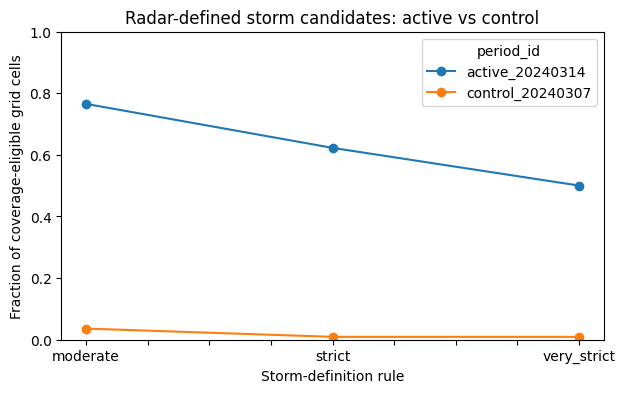

In [9]:
plot_table = (
    pilot_control_summary[
        [
            "period_id",
            "rule",
            "candidate_fraction",
        ]
    ]
    .pivot(
        index="rule",
        columns="period_id",
        values="candidate_fraction",
    )
    .reindex(
        [
            "moderate",
            "strict",
            "very_strict",
        ]
    )
)


ax = plot_table.plot(
    marker="o",
    figsize=(7, 4),
)

ax.set_xlabel(
    "Storm-definition rule"
)

ax.set_ylabel(
    "Fraction of coverage-eligible grid cells"
)

ax.set_title(
    "Radar-defined storm candidates: active vs control"
)

ax.set_ylim(
    0,
    1,
)

plt.show()

### Pilot-versus-control interpretation

The pilot comparison is intended as a falsification check rather than a forecast-skill experiment.

A useful radar storm definition should satisfy two qualitative properties:

1. it should retain substantial convective structure in the hail-active pilot;
2. it should produce relatively few storm candidates in the independent quiet/control hour.

The moderate rule is intentionally permissive.

The very-strict rule requires twice the persistence of the strict rule and therefore risks excluding shorter-lived but meteorologically meaningful convection.

The **strict** rule is carried forward as the provisional working definition:

$$
Z \ge 35\text{ dBZ},
$$

with at least 10% full-cell spatial support in at least five usable scans, subject to the 80%/80% coverage criteria.

This choice is provisional rather than final validation. Independent hail-active periods are used next to test whether the rule continues to capture observed hail cases without relaxing the frozen definition.

In [10]:
STORM_RULE = "strict"

STORM_COLUMN = (
    "storm_candidate_strict"
)


pilot_grid[
    "storm_indicator"
] = (
    pilot_grid[
        STORM_COLUMN
    ]
    .astype(bool)
)


control_grid[
    "storm_indicator"
] = (
    control_grid[
        STORM_COLUMN
    ]
    .astype(bool)
)


print(
    "Frozen working storm rule:",
    STORM_RULE,
)

print(
    "Active strict candidates:",
    int(
        pilot_grid[
            "storm_indicator"
        ].sum()
    ),
)

print(
    "Control strict candidates:",
    int(
        control_grid[
            "storm_indicator"
        ].sum()
    ),
)

Frozen working storm rule: strict
Active strict candidates: 61
Control strict candidates: 1


## 4. Multi-period hail-active validation

The pilot hour was used during storm-rule development and therefore cannot serve as independent validation.

The frozen processing pipeline is next applied to additional hail-active periods from 2024.

Four candidate periods were identified during exploratory screening:

- `active_20240331`
- `active_20240418`
- `active_20240508`
- `active_20240526`

The March 31 period is retained in the audit because it provides a useful radar-coverage stress case. Its usable radar domain was substantially smaller than the other periods, so the primary multi-period validation focuses on the latter three periods.

No storm-definition threshold is changed across periods.

Each period is processed using exactly the same:

- MRMS product;
- spatial domain;
- 0.25° coarse grid;
- 80% fine-pixel coverage rule;
- 80% grid-hour coverage rule;
- 35-dBZ reflectivity threshold;
- moderate, strict, and very-strict persistence definitions.

NOAA hail reports are not used to construct $S$. They are overlaid only after the radar-defined storm fields have been generated.

In [11]:
# ------------------------------------------------------------
# Additional hail-active validation periods
# ------------------------------------------------------------

ACTIVE_VALIDATION_PLAN = pd.DataFrame(
    {
        "period_id": [
            "active_20240331",
            "active_20240418",
            "active_20240508",
            "active_20240526",
        ],

        "local_hour": pd.to_datetime(
            [
                "2024-03-31 18:00:00",
                "2024-04-18 16:00:00",
                "2024-05-08 15:00:00",
                "2024-05-26 16:00:00",
            ]
        ),

        "start_utc": pd.to_datetime(
            [
                "2024-04-01 00:00:00",
                "2024-04-18 22:00:00",
                "2024-05-08 21:00:00",
                "2024-05-26 22:00:00",
            ]
        ),
    }
)


ACTIVE_VALIDATION_PLAN[
    "end_utc"
] = (
    ACTIVE_VALIDATION_PLAN[
        "start_utc"
    ]
    + pd.Timedelta(
        hours=1
    )
    - pd.Timedelta(
        seconds=1
    )
)


VALIDATION_RADAR_DIR = (
    MRMS_DIR
    / "validation"
)


ACTIVE_VALIDATION_PLAN[
    "period_dir"
] = (
    ACTIVE_VALIDATION_PLAN[
        "period_id"
    ]
    .map(
        lambda period_id:
            VALIDATION_RADAR_DIR
            / period_id
    )
)


# ------------------------------------------------------------
# Primary periods retained after radar-coverage screening
# ------------------------------------------------------------

PRIMARY_VALIDATION_PERIODS = [
    "active_20240418",
    "active_20240508",
    "active_20240526",
]


# ------------------------------------------------------------
# Check local inputs
# ------------------------------------------------------------

for path in (
    ACTIVE_VALIDATION_PLAN[
        "period_dir"
    ]
):

    if not path.exists():

        raise FileNotFoundError(
            f"Validation MRMS directory not found: {path}"
        )


# ------------------------------------------------------------
# Public-facing plan
# ------------------------------------------------------------

display(
    ACTIVE_VALIDATION_PLAN[
        [
            "period_id",
            "local_hour",
            "start_utc",
            "end_utc",
        ]
    ]
)

,period_id,local_hour,start_utc,end_utc
0,active_20240331,2024-03-31 18:00:00,2024-04-01 00:00:00,2024-04-01 00:59:59
1,active_20240418,2024-04-18 16:00:00,2024-04-18 22:00:00,2024-04-18 22:59:59
2,active_20240508,2024-05-08 15:00:00,2024-05-08 21:00:00,2024-05-08 21:59:59
3,active_20240526,2024-05-26 16:00:00,2024-05-26 22:00:00,2024-05-26 22:59:59


In [ ]:
# ------------------------------------------------------------
# Reprocess every hail-active period using the finalized
# MRMS storm pipeline
# ------------------------------------------------------------

active_grid_tables = {}
active_file_tables = {}


for _, period in (
    ACTIVE_VALIDATION_PLAN
    .iterrows()
):

    period_id = (
        period[
            "period_id"
        ]
    )


    print(
        "Processing:",
        period_id,
    )


    grid_df, file_table = (
        process_mrms_period(
            period_id=
                period_id,

            period_dir=
                period[
                    "period_dir"
                ],

            start_utc=
                period[
                    "start_utc"
                ],

            end_utc=
                period[
                    "end_utc"
                ],
        )
    )


    active_grid_tables[
        period_id
    ] = grid_df


    active_file_tables[
        period_id
    ] = file_table


print(
    "\nProcessed active periods:",
    len(
        active_grid_tables
    ),
)

In [13]:
# ------------------------------------------------------------
# Summarize corrected storm-rule behavior
# across hail-active periods
# ------------------------------------------------------------

active_summary_tables = []


for period_id, grid_df in (
    active_grid_tables.items()
):

    period_summary = (
        summarize_storm_period(
            grid_df
        )
    )


    period_summary[
        "primary_validation_period"
    ] = (
        period_id
        in PRIMARY_VALIDATION_PERIODS
    )


    active_summary_tables.append(
        period_summary
    )


active_validation_summary = (
    pd.concat(
        active_summary_tables,
        ignore_index=True,
    )
)


display(
    active_validation_summary
)

,period_id,rule,radar_scans,eligible_cells,candidate_cells,candidate_fraction,primary_validation_period
0,active_20240331,moderate,30,7,7,1.000000,False
1,active_20240331,strict,30,7,6,0.857143,False
2,active_20240331,very_strict,30,7,4,0.571429,False
3,active_20240418,moderate,30,58,47,0.810345,True
4,active_20240418,strict,30,58,45,0.775862,True
5,active_20240418,very_strict,30,58,38,0.655172,True
6,active_20240508,moderate,30,54,43,0.796296,True
7,active_20240508,strict,30,54,40,0.740741,True
8,active_20240508,very_strict,30,54,31,0.574074,True
9,active_20240526,moderate,30,57,44,0.771930,True


## 5. Overlay NOAA hail observations

Storm occurrence has now been defined entirely from MRMS radar.

Only at this stage are NOAA hail observations introduced.

Because NOAA event times are recorded in local time, each report is first converted to UTC using the explicit fixed offset encoded in `CZ_TIMEZONE`, when available.

Reports are then matched to the same UTC analysis window used by the MRMS storm field.

For each hail-active period:

1. NOAA event times are converted from local time to UTC;
2. reports are restricted to the same UTC radar hour and geographic domain;
3. each report is mapped to the corresponding 0.25° coarse grid cell;
4. multiple reports within one coarse cell are collapsed into a single hail-positive grid cell;
5. the hail indicator is defined as

$$
H =
\begin{cases}
1, & \text{at least one NOAA hail report in the grid cell},\\
0, & \text{no NOAA hail report in the grid cell}.
\end{cases}
$$

Importantly,

$$
H=0
$$

means **no observed NOAA hail report**.

It does not prove physical hail absence.

Hail-positive cells that fail the radar storm rule are retained as $S=0,H=1$ diagnostic cases rather than being silently discarded.

In [14]:
# ------------------------------------------------------------
# Load NOAA hail observations
# ------------------------------------------------------------

hail = pd.read_csv(
    HAIL_PATH,
    low_memory=False,
)


# ------------------------------------------------------------
# Parse local event time and location
# ------------------------------------------------------------

hail[
    "begin_local"
] = pd.to_datetime(
    hail[
        "BEGIN_DATE_TIME"
    ],
    errors="coerce",
)


hail[
    "BEGIN_LAT"
] = pd.to_numeric(
    hail[
        "BEGIN_LAT"
    ],
    errors="coerce",
)


hail[
    "BEGIN_LON"
] = pd.to_numeric(
    hail[
        "BEGIN_LON"
    ],
    errors="coerce",
)


# ------------------------------------------------------------
# Restrict to hail records if EVENT_TYPE is available
# ------------------------------------------------------------

if "EVENT_TYPE" in hail.columns:

    hail = hail[
        hail[
            "EVENT_TYPE"
        ]
        .astype(str)
        .str.lower()
        .eq(
            "hail"
        )
    ].copy()


# ============================================================
# Convert NOAA local event time to UTC
#
# Examples:
#   CST-6 -> UTC = local + 6 h
#   EST-5 -> UTC = local + 5 h
#   MST-7 -> UTC = local + 7 h
#
# Records without an explicit numeric offset are left
# unresolved rather than assigned an assumed timezone.
# ============================================================

if "CZ_TIMEZONE" not in hail.columns:

    raise KeyError(
        "CZ_TIMEZONE is required for UTC alignment."
    )


timezone_offset_text = (
    hail[
        "CZ_TIMEZONE"
    ]
    .astype("string")
    .str.extract(
        r"([+-]\d+)$",
        expand=False,
    )
)


hail[
    "utc_offset_hours"
] = pd.to_numeric(
    timezone_offset_text,
    errors="coerce",
)


hail[
    "begin_utc"
] = (
    hail[
        "begin_local"
    ]
    -
    pd.to_timedelta(
        hail[
            "utc_offset_hours"
        ],
        unit="h",
    )
)


# ------------------------------------------------------------
# Audit conversion availability
# ------------------------------------------------------------

print(
    "NOAA hail records:",
    f"{len(hail):,}",
)

print(
    "Records with explicit UTC offset:",
    f"{hail['begin_utc'].notna().sum():,}",
)

print(
    "Records without explicit UTC offset:",
    f"{hail['begin_utc'].isna().sum():,}",
)


# ------------------------------------------------------------
# Grid-assignment helper
# ------------------------------------------------------------

def assign_report_to_coarse_grid(
    reports,
):
    """
    Map point hail reports to the fixed 0.25-degree grid
    used by the MRMS storm fields.
    """

    out = reports.copy()


    # --------------------------------------------------------
    # Restrict to study domain
    # --------------------------------------------------------

    in_domain = (
        out[
            "BEGIN_LAT"
        ]
        .ge(
            LAT_MIN
        )
        &
        out[
            "BEGIN_LAT"
        ]
        .lt(
            LAT_MAX
        )
        &
        out[
            "BEGIN_LON"
        ]
        .ge(
            LON_MIN
        )
        &
        out[
            "BEGIN_LON"
        ]
        .lt(
            LON_MAX
        )
    )


    out = (
        out[
            in_domain
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Assign fixed 0.25-degree coarse-grid centers
    # --------------------------------------------------------

    out[
        "grid_lat"
    ] = (
        LAT_MIN
        + COARSE_GRID_DEG / 2
        + np.floor(
            (
                out[
                    "BEGIN_LAT"
                ]
                - LAT_MIN
            )
            / COARSE_GRID_DEG
        )
        * COARSE_GRID_DEG
    )


    out[
        "grid_lon"
    ] = (
        LON_MIN
        + COARSE_GRID_DEG / 2
        + np.floor(
            (
                out[
                    "BEGIN_LON"
                ]
                - LON_MIN
            )
            / COARSE_GRID_DEG
        )
        * COARSE_GRID_DEG
    )


    # --------------------------------------------------------
    # Stable merge keys
    # --------------------------------------------------------

    out[
        "grid_lat_key"
    ] = (
        out[
            "grid_lat"
        ]
        .round(
            3
        )
    )


    out[
        "grid_lon_key"
    ] = (
        out[
            "grid_lon"
        ]
        .round(
            3
        )
    )


    return out

NOAA hail records: 414,795
Records with explicit UTC offset: 198,508
Records without explicit UTC offset: 216,287


In [15]:
# ------------------------------------------------------------
# Extract correctly time-aligned hail reports
# for each validation period
# ------------------------------------------------------------

active_hail_reports = {}
active_hail_cells = {}

hail_report_summary_rows = []


for _, period in (
    ACTIVE_VALIDATION_PLAN
    .iterrows()
):

    period_id = (
        period[
            "period_id"
        ]
    )


    start_utc = pd.Timestamp(
        period[
            "start_utc"
        ]
    )


    end_utc = pd.Timestamp(
        period[
            "end_utc"
        ]
    )


    # ========================================================
    # Temporal matching is performed in UTC.
    # ========================================================

    period_hail = hail[
        (
            hail[
                "begin_utc"
            ]
            >= start_utc
        )
        &
        (
            hail[
                "begin_utc"
            ]
            <= end_utc
        )
    ].copy()


    # --------------------------------------------------------
    # Spatial restriction + coarse-grid assignment
    # --------------------------------------------------------

    period_hail = (
        assign_report_to_coarse_grid(
            period_hail
        )
    )


    # --------------------------------------------------------
    # Audit actual timezone labels among retained reports
    # --------------------------------------------------------

    timezone_values = (
        period_hail[
            "CZ_TIMEZONE"
        ]
        .dropna()
        .astype(str)
        .unique()
    )


    # --------------------------------------------------------
    # Collapse multiple reports within the same coarse cell
    # --------------------------------------------------------

    hail_cells = (
        period_hail[
            [
                "grid_lat_key",
                "grid_lon_key",
            ]
        ]
        .drop_duplicates()
        .reset_index(
            drop=True
        )
    )


    active_hail_reports[
        period_id
    ] = period_hail


    active_hail_cells[
        period_id
    ] = hail_cells


    hail_report_summary_rows.append(
        {
            "period_id":
                period_id,

            "radar_start_utc":
                start_utc,

            "radar_end_utc":
                end_utc,

            "raw_hail_reports_in_domain":
                len(
                    period_hail
                ),

            "unique_hail_grid_cells":
                len(
                    hail_cells
                ),

            "recorded_timezones":
                ", ".join(
                    sorted(
                        timezone_values
                    )
                ),
        }
    )


hail_report_summary = pd.DataFrame(
    hail_report_summary_rows
)


display(
    hail_report_summary
)

,period_id,radar_start_utc,radar_end_utc,raw_hail_reports_in_domain,unique_hail_grid_cells,recorded_timezones
0,active_20240331,2024-04-01 00:00:00,2024-04-01 00:59:59,22,3,CST-6
1,active_20240418,2024-04-18 22:00:00,2024-04-18 22:59:59,6,4,CST-6
2,active_20240508,2024-05-08 21:00:00,2024-05-08 21:59:59,8,4,CST-6
3,active_20240526,2024-05-26 22:00:00,2024-05-26 22:59:59,9,8,CST-6


In [16]:
def overlay_hail_on_storm_grid(
    grid_df,
    hail_cells,
):
    """
    Overlay NOAA hail-positive coarse cells onto an
    already-constructed radar storm grid.
    """

    out = grid_df.copy()


    # --------------------------------------------------------
    # Stable merge keys
    # --------------------------------------------------------

    out[
        "grid_lat_key"
    ] = (
        out[
            "grid_lat"
        ]
        .round(
            3
        )
    )


    out[
        "grid_lon_key"
    ] = (
        out[
            "grid_lon"
        ]
        .round(
            3
        )
    )


    hail_keys = hail_cells.copy()

    hail_keys[
        "hail_positive"
    ] = True


    out = out.merge(
        hail_keys,
        on=[
            "grid_lat_key",
            "grid_lon_key",
        ],
        how="left",
    )


    out[
        "hail_positive"
    ] = (
        out[
            "hail_positive"
        ]
        .eq(
            True
        )
    )


    out[
        "storm_indicator"
    ] = (
        out[
            STORM_COLUMN
        ]
        .astype(bool)
    )


    return out

In [17]:
# ------------------------------------------------------------
# Overlay hail and audit storm-rule capture
# ------------------------------------------------------------

storm_hail_tables = {}
hail_capture_rows = []


for period_id, grid_df in (
    active_grid_tables.items()
):

    labeled_grid = (
        overlay_hail_on_storm_grid(
            grid_df=
                grid_df,

            hail_cells=
                active_hail_cells[
                    period_id
                ],
        )
    )


    storm_hail_tables[
        period_id
    ] = labeled_grid


    hail_mask = (
        labeled_grid[
            "hail_positive"
        ]
    )


    eligible_hail_mask = (
        hail_mask
        &
        labeled_grid[
            "coverage_eligible"
        ]
        .astype(bool)
    )


    n_hail_cells = int(
        hail_mask.sum()
    )


    n_eligible_hail = int(
        eligible_hail_mask.sum()
    )


    moderate_captured = int(
        (
            eligible_hail_mask
            &
            labeled_grid[
                "storm_candidate_moderate"
            ]
            .astype(bool)
        )
        .sum()
    )


    strict_captured = int(
        (
            eligible_hail_mask
            &
            labeled_grid[
                "storm_candidate_strict"
            ]
            .astype(bool)
        )
        .sum()
    )


    very_strict_captured = int(
        (
            eligible_hail_mask
            &
            labeled_grid[
                "storm_candidate_very_strict"
            ]
            .astype(bool)
        )
        .sum()
    )


    hail_capture_rows.append(
        {
            "period_id":
                period_id,

            "primary_validation_period":
                (
                    period_id
                    in PRIMARY_VALIDATION_PERIODS
                ),

            "hail_positive_cells":
                n_hail_cells,

            "coverage_eligible_hail_cells":
                n_eligible_hail,

            "moderate_captured":
                moderate_captured,

            "strict_captured":
                strict_captured,

            "very_strict_captured":
                very_strict_captured,

            "strict_H1_S0":
                (
                    n_eligible_hail
                    - strict_captured
                ),

            "strict_capture_rate":
                (
                    strict_captured
                    / n_eligible_hail
                    if n_eligible_hail > 0
                    else np.nan
                ),
        }
    )


hail_capture_summary = pd.DataFrame(
    hail_capture_rows
)


display(
    hail_capture_summary
)

,period_id,primary_validation_period,hail_positive_cells,coverage_eligible_hail_cells,moderate_captured,strict_captured,very_strict_captured,strict_H1_S0,strict_capture_rate
0,active_20240331,False,3,1,1,1,1,0,1.0
1,active_20240418,True,4,2,2,2,2,0,1.0
2,active_20240508,True,4,4,4,4,4,0,1.0
3,active_20240526,True,8,7,7,7,6,0,1.0


## 6. Matched no-hail control validation

Hail capture alone is not sufficient to validate a storm proxy.

A definition that labels nearly every coverage-eligible grid cell as a storm could achieve high hail capture while providing little discrimination between convectively active and quiet periods.

A complementary control analysis is therefore retained.

During exploratory development, candidate control hours were ranked by temporal proximity to each hail-active period and required to contain no NOAA hail reports within a wider ±3-hour screening window.

Candidates were then evaluated sequentially for MRMS coverage.

The first candidate satisfying both conditions was retained when possible:

1. no observed NOAA hail in the comparison window;
2. at least 25% of the study domain is coverage eligible under the frozen 80%/80% radar-coverage rule.

Two primary hail-active periods had usable matched controls:

- 2024-04-18 → control on 2024-04-25 22 UTC;
- 2024-05-08 → control on 2024-04-03 21 UTC.

No satisfactory matched control was available for the 2024-05-26 period under the same screening procedure.

Matched controls are used only as supporting validation of the storm proxy. They are not required to construct the storm-conditioned sample frame.

In [18]:
# ------------------------------------------------------------
# Selected matched controls from the exploratory
# coverage-aware sequential search
# ------------------------------------------------------------

CONTROL_MRMS_DIR = (
    MRMS_DIR
    / "control_rank1"
)


SELECTED_CONTROL_PLAN = pd.DataFrame(
    {
        "active_period_id": [
            "active_20240418",
            "active_20240508",
        ],

        "control_period_id": [
            "active_20240418_rank2",
            "active_20240508_rank9",
        ],

        "candidate_rank": [
            2,
            9,
        ],

        "offset_days": [
            7,
            -35,
        ],

        "start_utc": pd.to_datetime(
            [
                "2024-04-25 22:00:00",
                "2024-04-03 21:00:00",
            ]
        ),
    }
)


SELECTED_CONTROL_PLAN[
    "end_utc"
] = (
    SELECTED_CONTROL_PLAN[
        "start_utc"
    ]
    + pd.Timedelta(
        hours=1
    )
    - pd.Timedelta(
        seconds=1
    )
)


SELECTED_CONTROL_PLAN[
    "period_dir"
] = (
    SELECTED_CONTROL_PLAN[
        "control_period_id"
    ]
    .map(
        lambda period_id:
            CONTROL_MRMS_DIR
            / period_id
    )
)


# ------------------------------------------------------------
# Restrict NOAA hail archive to the study domain
# ------------------------------------------------------------

hail_in_domain = hail[
    hail[
        "BEGIN_LAT"
    ]
    .ge(
        LAT_MIN
    )
    &
    hail[
        "BEGIN_LAT"
    ]
    .lt(
        LAT_MAX
    )
    &
    hail[
        "BEGIN_LON"
    ]
    .ge(
        LON_MIN
    )
    &
    hail[
        "BEGIN_LON"
    ]
    .lt(
        LON_MAX
    )
].copy()


# ------------------------------------------------------------
# Re-audit hail-free status using the corrected UTC timestamps
# ------------------------------------------------------------

control_audit_rows = []


for _, control in (
    SELECTED_CONTROL_PLAN
    .iterrows()
):

    start_utc = pd.Timestamp(
        control[
            "start_utc"
        ]
    )

    end_utc = pd.Timestamp(
        control[
            "end_utc"
        ]
    )


    exact_hour = hail_in_domain[
        hail_in_domain[
            "begin_utc"
        ]
        .between(
            start_utc,
            end_utc,
            inclusive="both",
        )
    ]


    wide_start = (
        start_utc
        - pd.Timedelta(
            hours=3
        )
    )

    wide_end = (
        end_utc
        + pd.Timedelta(
            hours=3
        )
    )


    plus_minus_3h = hail_in_domain[
        hail_in_domain[
            "begin_utc"
        ]
        .between(
            wide_start,
            wide_end,
            inclusive="both",
        )
    ]


    period_dir = (
        control[
            "period_dir"
        ]
    )


    if not period_dir.exists():

        raise FileNotFoundError(
            "Matched-control MRMS directory not found: "
            f"{period_dir}"
        )


    control_audit_rows.append(
        {
            "active_period_id":
                control[
                    "active_period_id"
                ],

            "control_period_id":
                control[
                    "control_period_id"
                ],

            "candidate_rank":
                int(
                    control[
                        "candidate_rank"
                    ]
                ),

            "offset_days":
                int(
                    control[
                        "offset_days"
                    ]
                ),

            "start_utc":
                start_utc,

            "hail_reports_exact_hour":
                len(
                    exact_hour
                ),

            "hail_reports_plus_minus_3h":
                len(
                    plus_minus_3h
                ),
        }
    )


selected_control_audit = pd.DataFrame(
    control_audit_rows
)


display(
    selected_control_audit
)


assert (
    selected_control_audit[
        "hail_reports_exact_hour"
    ]
    == 0
).all()


assert (
    selected_control_audit[
        "hail_reports_plus_minus_3h"
    ]
    == 0
).all()

,active_period_id,control_period_id,candidate_rank,offset_days,start_utc,hail_reports_exact_hour,hail_reports_plus_minus_3h
0,active_20240418,active_20240418_rank2,2,7,2024-04-25 22:00:00,0,0
1,active_20240508,active_20240508_rank9,9,-35,2024-04-03 21:00:00,0,0


In [ ]:
# ------------------------------------------------------------
# Reprocess selected matched controls using exactly the same
# corrected storm-processing function as the active periods
# ------------------------------------------------------------

control_grid_tables = {}
control_file_tables = {}


for _, control in (
    SELECTED_CONTROL_PLAN
    .iterrows()
):

    control_id = (
        control[
            "control_period_id"
        ]
    )


    print(
        "Processing matched control:",
        control_id,
    )


    grid_df, file_table = (
        process_mrms_period(
            period_id=
                control_id,

            period_dir=
                control[
                    "period_dir"
                ],

            start_utc=
                control[
                    "start_utc"
                ],

            end_utc=
                control[
                    "end_utc"
                ],
        )
    )


    control_grid_tables[
        control_id
    ] = grid_df


    control_file_tables[
        control_id
    ] = file_table


print(
    "\nProcessed matched controls:",
    len(
        control_grid_tables
    ),
)

In [20]:
# ------------------------------------------------------------
# Summarize matched controls
# ------------------------------------------------------------

control_summary_tables = []


for _, control in (
    SELECTED_CONTROL_PLAN
    .iterrows()
):

    control_id = (
        control[
            "control_period_id"
        ]
    )


    summary = (
        summarize_storm_period(
            control_grid_tables[
                control_id
            ]
        )
    )


    summary[
        "active_period_id"
    ] = (
        control[
            "active_period_id"
        ]
    )


    control_summary_tables.append(
        summary
    )


matched_control_summary = (
    pd.concat(
        control_summary_tables,
        ignore_index=True,
    )
)


# ------------------------------------------------------------
# Pull corresponding active-period summaries
# ------------------------------------------------------------

matched_active_ids = (
    SELECTED_CONTROL_PLAN[
        "active_period_id"
    ]
    .tolist()
)


matched_active_summary = (
    active_validation_summary[
        active_validation_summary[
            "period_id"
        ]
        .isin(
            matched_active_ids
        )
    ]
    .copy()
)


# ------------------------------------------------------------
# Build paired comparison
# ------------------------------------------------------------

active_compare = (
    matched_active_summary[
        [
            "period_id",
            "rule",
            "eligible_cells",
            "candidate_cells",
            "candidate_fraction",
        ]
    ]
    .rename(
        columns={
            "period_id":
                "active_period_id",

            "eligible_cells":
                "active_eligible_cells",

            "candidate_cells":
                "active_candidate_cells",

            "candidate_fraction":
                "active_candidate_fraction",
        }
    )
)


control_compare = (
    matched_control_summary[
        [
            "active_period_id",
            "period_id",
            "rule",
            "eligible_cells",
            "candidate_cells",
            "candidate_fraction",
        ]
    ]
    .rename(
        columns={
            "period_id":
                "control_period_id",

            "eligible_cells":
                "control_eligible_cells",

            "candidate_cells":
                "control_candidate_cells",

            "candidate_fraction":
                "control_candidate_fraction",
        }
    )
)


matched_storm_comparison = (
    active_compare
    .merge(
        control_compare,
        on=[
            "active_period_id",
            "rule",
        ],
        how="inner",
        validate="one_to_one",
    )
)


display(
    matched_storm_comparison
)

,active_period_id,rule,active_eligible_cells,active_candidate_cells,active_candidate_fraction,control_period_id,control_eligible_cells,control_candidate_cells,control_candidate_fraction
0,active_20240418,moderate,58,47,0.810345,active_20240418_rank2,71,11,0.154930
1,active_20240418,strict,58,45,0.775862,active_20240418_rank2,71,9,0.126761
2,active_20240418,very_strict,58,38,0.655172,active_20240418_rank2,71,7,0.098592
3,active_20240508,moderate,54,43,0.796296,active_20240508_rank9,97,0,0.000000
4,active_20240508,strict,54,40,0.740741,active_20240508_rank9,97,0,0.000000
5,active_20240508,very_strict,54,31,0.574074,active_20240508_rank9,97,0,0.000000


### Matched-control interpretation

The matched-control comparison provides a complementary check on the radar storm proxy.

For both hail-active periods with usable controls, radar-defined storm fractions are substantially larger during the hail-active hour than during the selected no-hail comparison hour.

This result matters because high hail capture alone could be obtained by an overly permissive storm definition.

The control comparison shows that the working rules do not simply classify all coverage-eligible grid cells as storms.

The strict rule is therefore retained because it satisfies two pilot requirements simultaneously:

1. it captures all coverage-eligible hail-positive cells in the three primary validation periods;
2. it remains substantially more selective during independently screened no-hail control hours.

Matched-control availability is nevertheless limited by MRMS coverage.

For this reason, the matched-control analysis is treated as **supporting validation**, not as part of the definition of the final storm-conditioned sample.

## 7. Construct the storm-first sample frame

The final pilot sample is constructed from the three primary hail-active validation periods:

- `active_20240418`;
- `active_20240508`;
- `active_20240526`.

The March 31 period is retained as a radar-coverage stress test but is excluded from the primary sample because only a very small fraction of the spatial domain satisfies the frozen coverage criterion.

Matched controls are also excluded from the storm-conditioned sample.

Their purpose is validation of the radar storm proxy rather than estimation of the within-storm hail sample.

For every primary grid-hour with adequate radar coverage, the independently constructed variables are:

$$
S =
\begin{cases}
1, & \text{strict radar storm criterion satisfied},\\
0, & \text{strict radar storm criterion not satisfied},
\end{cases}
$$

and

$$
H =
\begin{cases}
1, & \text{at least one observed NOAA hail report},\\
0, & \text{no observed NOAA hail report}.
\end{cases}
$$

This creates four observable categories:

- $S=0,H=0$ — no radar-defined storm and no observed hail;
- $S=1,H=0$ — radar-defined storm without observed hail;
- $S=1,H=1$ — radar-defined storm with observed hail;
- $S=0,H=1$ — observed hail not captured by the working storm rule.

Coverage-ineligible grid-hours remain outside this classification rather than being interpreted as $S=0$.

In [21]:
# ------------------------------------------------------------
# Combine only the three primary validation periods
# ------------------------------------------------------------

primary_labeled_tables = [
    storm_hail_tables[
        period_id
    ].copy()
    for period_id
    in PRIMARY_VALIDATION_PERIODS
]


storm_hail_grid = (
    pd.concat(
        primary_labeled_tables,
        ignore_index=True,
    )
)


# ------------------------------------------------------------
# Standardize binary indicators
# ------------------------------------------------------------

storm_hail_grid[
    "coverage_eligible"
] = (
    storm_hail_grid[
        "coverage_eligible"
    ]
    .astype(bool)
)


storm_hail_grid[
    "storm_indicator"
] = (
    storm_hail_grid[
        STORM_COLUMN
    ]
    .astype(bool)
)


storm_hail_grid[
    "hail_positive"
] = (
    storm_hail_grid[
        "hail_positive"
    ]
    .astype(bool)
)


print(
    "Primary periods:",
    storm_hail_grid[
        "period_id"
    ].nunique(),
)

print(
    "Total grid-hours:",
    len(
        storm_hail_grid
    ),
)

print(
    "Coverage-eligible grid-hours:",
    int(
        storm_hail_grid[
            "coverage_eligible"
        ]
        .sum()
    ),
)

Primary periods: 3
Total grid-hours: 504
Coverage-eligible grid-hours: 169


In [22]:
# ------------------------------------------------------------
# Assign observable S/H categories
# ------------------------------------------------------------

storm_hail_grid[
    "sample_category"
] = "coverage_ineligible"


eligible = (
    storm_hail_grid[
        "coverage_eligible"
    ]
)


storm = (
    storm_hail_grid[
        "storm_indicator"
    ]
)


hail_obs = (
    storm_hail_grid[
        "hail_positive"
    ]
)


storm_hail_grid.loc[
    eligible
    &
    (~storm)
    &
    (~hail_obs),
    "sample_category",
] = "S0_H0"


storm_hail_grid.loc[
    eligible
    &
    storm
    &
    (~hail_obs),
    "sample_category",
] = "S1_H0"


storm_hail_grid.loc[
    eligible
    &
    storm
    &
    hail_obs,
    "sample_category",
] = "S1_H1"


storm_hail_grid.loc[
    eligible
    &
    (~storm)
    &
    hail_obs,
    "sample_category",
] = "S0_H1"


category_summary = (
    storm_hail_grid[
        "sample_category"
    ]
    .value_counts()
    .rename_axis(
        "sample_category"
    )
    .reset_index(
        name="count"
    )
)


display(
    category_summary
)


# ------------------------------------------------------------
# Construct storm-conditioned sample
# ------------------------------------------------------------

storm_first_sample = (
    storm_hail_grid[
        storm_hail_grid[
            "coverage_eligible"
        ]
        &
        storm_hail_grid[
            "storm_indicator"
        ]
    ]
    .copy()
)


storm_first_sample[
    "S"
] = 1


storm_first_sample[
    "H"
] = (
    storm_first_sample[
        "hail_positive"
    ]
    .astype(int)
)


print(
    "\nStorm-conditioned samples:",
    len(
        storm_first_sample
    ),
)

print(
    "S=1, H=1:",
    int(
        storm_first_sample[
            "H"
        ]
        .sum()
    ),
)

print(
    "S=1, H=0:",
    int(
        (
            storm_first_sample[
                "H"
            ]
            == 0
        )
        .sum()
    ),
)

print(
    "Observed hail fraction:",
    round(
        storm_first_sample[
            "H"
        ]
        .mean(),
        4,
    ),
)

,sample_category,count
0,coverage_ineligible,335
1,S1_H0,110
2,S0_H0,46
3,S1_H1,13



Storm-conditioned samples: 123
S=1, H=1: 13
S=1, H=0: 110
Observed hail fraction: 0.1057


In [23]:
# ------------------------------------------------------------
# Period-level storm-first summary
# ------------------------------------------------------------

period_summary_rows = []


for period_id in (
    PRIMARY_VALIDATION_PERIODS
):

    period_grid = (
        storm_hail_grid[
            storm_hail_grid[
                "period_id"
            ]
            == period_id
        ]
    )


    period_storm = (
        period_grid[
            period_grid[
                "coverage_eligible"
            ]
            &
            period_grid[
                "storm_indicator"
            ]
        ]
    )


    n_storm = len(
        period_storm
    )


    n_hail = int(
        period_storm[
            "hail_positive"
        ]
        .sum()
    )


    n_s0_h1 = int(
        (
            period_grid[
                "coverage_eligible"
            ]
            &
            (~period_grid[
                "storm_indicator"
            ])
            &
            period_grid[
                "hail_positive"
            ]
        )
        .sum()
    )


    period_summary_rows.append(
        {
            "period_id":
                period_id,

            "coverage_eligible_grid_hours":
                int(
                    period_grid[
                        "coverage_eligible"
                    ]
                    .sum()
                ),

            "storm_samples":
                n_storm,

            "S1_H1":
                n_hail,

            "S1_H0":
                n_storm
                - n_hail,

            "hail_fraction_given_storm":
                (
                    n_hail
                    / n_storm
                    if n_storm > 0
                    else np.nan
                ),

            "S0_H1":
                n_s0_h1,
        }
    )


storm_first_summary = pd.DataFrame(
    period_summary_rows
)


display(
    storm_first_summary
)

,period_id,coverage_eligible_grid_hours,storm_samples,S1_H1,S1_H0,hail_fraction_given_storm,S0_H1
0,active_20240418,58,45,2,43,0.044444,0
1,active_20240508,54,40,4,36,0.100000,0
2,active_20240526,57,38,7,31,0.184211,0


In [24]:
# ------------------------------------------------------------
# Final internal consistency checks
# ------------------------------------------------------------

duplicate_grid_hours = int(
    storm_hail_grid
    .duplicated(
        subset=[
            "period_id",
            "grid_lat_key",
            "grid_lon_key",
        ]
    )
    .sum()
)


n_total = len(
    storm_hail_grid
)


n_eligible = int(
    storm_hail_grid[
        "coverage_eligible"
    ]
    .sum()
)


n_ineligible = (
    n_total
    - n_eligible
)


n_s1_h1 = int(
    (
        storm_hail_grid[
            "sample_category"
        ]
        == "S1_H1"
    )
    .sum()
)


n_s1_h0 = int(
    (
        storm_hail_grid[
            "sample_category"
        ]
        == "S1_H0"
    )
    .sum()
)


n_s0_h0 = int(
    (
        storm_hail_grid[
            "sample_category"
        ]
        == "S0_H0"
    )
    .sum()
)


n_s0_h1 = int(
    (
        storm_hail_grid[
            "sample_category"
        ]
        == "S0_H1"
    )
    .sum()
)


n_storm = int(
    (
        storm_hail_grid[
            "coverage_eligible"
        ]
        &
        storm_hail_grid[
            "storm_indicator"
        ]
    )
    .sum()
)


qc_summary = pd.DataFrame(
    {
        "check": [
            "Duplicate period-grid rows",
            "Total grid-hours",
            "Coverage-eligible grid-hours",
            "Coverage-ineligible grid-hours",
            "Strict storm grid-hours",
            "S1_H1",
            "S1_H0",
            "S0_H0",
            "S0_H1",
            "Eligible categories reconcile",
            "Storm categories reconcile",
        ],

        "value": [
            duplicate_grid_hours,
            n_total,
            n_eligible,
            n_ineligible,
            n_storm,
            n_s1_h1,
            n_s1_h0,
            n_s0_h0,
            n_s0_h1,
            (
                n_s1_h1
                + n_s1_h0
                + n_s0_h0
                + n_s0_h1
                == n_eligible
            ),
            (
                n_s1_h1
                + n_s1_h0
                == n_storm
            ),
        ],
    }
)


display(
    qc_summary
)


# ------------------------------------------------------------
# Structural assertions
# ------------------------------------------------------------

assert duplicate_grid_hours == 0

assert (
    n_s1_h1
    + n_s1_h0
    + n_s0_h0
    + n_s0_h1
    == n_eligible
)

assert (
    n_s1_h1
    + n_s1_h0
    == n_storm
)

assert (
    storm_first_sample[
        "coverage_eligible"
    ]
    .all()
)

assert (
    storm_first_sample[
        "storm_indicator"
    ]
    .all()
)

,check,value
0,Duplicate period-grid rows,0
1,Total grid-hours,504
2,Coverage-eligible grid-hours,169
3,Coverage-ineligible grid-hours,335
4,Strict storm grid-hours,123
5,S1_H1,13
6,S1_H0,110
7,S0_H0,46
8,S0_H1,0
9,Eligible categories reconcile,True


## 8. Final pilot interpretation

The storm-first construction is successful as a methodological pilot.

The final sampling order is

$$
\text{MRMS radar}
\rightarrow
\text{coverage assessment}
\rightarrow
S
\rightarrow
\text{NOAA hail overlay}
\rightarrow
H.
$$

The working strict storm rule requires:

- valid reflectivity over at least 80% of the nominal fine pixels in a scan-cell;
- at least 80% of scans in the grid-hour to satisfy that coverage requirement;
- reflectivity of at least 35 dBZ;
- at least 10% of the **full nominal coarse-cell area** to exceed 35 dBZ;
- that spatial-support criterion to occur in at least five scans.

Across the three primary hail-active validation periods:

- 169 grid-hours are radar-coverage eligible;
- 13 hail-positive grid-hours are coverage eligible;
- the strict rule captures 13/13;
- the very-strict sensitivity rule captures 12/13.

The strict rule identifies 123 storm grid-hours, producing a storm-conditioned pilot sample with:

- 13 $S=1,H=1$ cases;
- 110 $S=1,H=0$ cases.

The matched-control analysis provides additional evidence that the radar rule is not merely labeling all observable grid cells as storms.

These results establish the feasibility of constructing samples for

$$
P(H=1 \mid S=1, X)
$$

without defining storm occurrence from the hail outcome itself.

### Limitations

This remains a pilot label-construction study.

In particular:

1. the primary periods were intentionally selected for hail activity;
2. grid cells within the same meteorological period are not independent observations;
3. $H=0$ means no observed NOAA hail report, not confirmed physical absence of hail;
4. the 35-dBZ and persistence criteria are operational pilot definitions rather than universal meteorological constants;
5. MRMS missingness is substantial and varies across periods;
6. the observed hail fraction in this enriched sample must not be interpreted as the natural population probability of hail given storm.

The next notebook therefore treats these storm labels as a fixed methodological input and performs an exploratory direct-versus-storm-conditioned hail-occurrence comparison under out-of-period validation.

That comparison is treated as a diagnostic modeling pilot rather than the final population-level forecasting experiment.

In [25]:
# ------------------------------------------------------------
# Save compact derived outputs for downstream notebooks
# ------------------------------------------------------------

OUTPUT_TABLE_DIR = (
    REPO_ROOT
    / "outputs"
    / "tables"
)


OUTPUT_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


storm_hail_grid.to_csv(
    OUTPUT_TABLE_DIR
    / "storm_first_grid.csv",
    index=False,
)


storm_first_sample.to_csv(
    OUTPUT_TABLE_DIR
    / "storm_conditioned_sample.csv",
    index=False,
)


storm_first_summary.to_csv(
    OUTPUT_TABLE_DIR
    / "storm_first_period_summary.csv",
    index=False,
)


hail_capture_summary.to_csv(
    OUTPUT_TABLE_DIR
    / "hail_capture_summary.csv",
    index=False,
)


matched_storm_comparison.to_csv(
    OUTPUT_TABLE_DIR
    / "matched_control_summary.csv",
    index=False,
)


print(
    "Saved derived tables under outputs/tables/."
)

Saved derived tables under outputs/tables/.
